# Week 3: Dataset Selection and Final Project Planning Lab


## 1. Data Selection
**Dataset name:** CDC Diabetes Health Indicators

**Source:** UCI Machine Learning Repository, https://archive.ics.uci.edu/dataset/891/cdc+diabetes+health+indicators

This dataset is from the CDC's 2015 Behavioral Risk Factor Surveillance System (BRFSS) survey and contains 253,680 individual responses with 21 predictor variables. The binary outcome variable is diabetes/prediabetes vs. no diabetes.

What drew me to this dataset is the socioeconomic angle. Income, education, and healthcare access show up here as direct, measured variables sitting right alongside clinical and behavioral indicators, which makes it a good fit for asking how socioeconomic position relates to diabetes risk at the individual level. Diabetes prevalence tracks closely with income and access to care, and with a large scale responses, this dataset lets me actually test that relationship instead of just inferring it from aggregate numbers.

## 2. Dataset Exploration

### 2.1 Import the dataset

In [40]:
# Install the UCI ML Repo
!pip install ucimlrepo

from ucimlrepo import fetch_ucirepo
import pandas as pd

# fetch dataset
cdc_diabetes_health_indicators = fetch_ucirepo(id=891)

# data (as pandas dataframes)
X = cdc_diabetes_health_indicators.data.features
y = cdc_diabetes_health_indicators.data.targets

df = pd.concat([X, y], axis=1)
df.head()


,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,Veggies,...,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income,Diabetes_binary
0,1,1,1,40,1,0,0,0,0,1,...,0,5,18,15,1,0,9,4,3,0
1,0,0,0,25,1,0,0,1,0,0,...,1,3,0,0,0,0,7,6,1,0
2,1,1,1,28,0,0,0,0,1,0,...,1,5,30,30,1,0,9,4,8,0
3,1,0,1,27,0,0,0,1,1,1,...,0,2,0,0,0,0,11,3,6,0
4,1,1,1,24,0,0,0,1,1,1,...,0,2,3,0,0,0,11,5,4,0


### 2.2. Dataset Structure

In [41]:
# Print dataset shape
print("Shape:", df.shape)
df.info()

Shape: (253680, 22)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 253680 entries, 0 to 253679
Data columns (total 22 columns):
 #   Column                Non-Null Count   Dtype
---  ------                --------------   -----
 0   HighBP                253680 non-null  int64
 1   HighChol              253680 non-null  int64
 2   CholCheck             253680 non-null  int64
 3   BMI                   253680 non-null  int64
 4   Smoker                253680 non-null  int64
 5   Stroke                253680 non-null  int64
 6   HeartDiseaseorAttack  253680 non-null  int64
 7   PhysActivity          253680 non-null  int64
 8   Fruits                253680 non-null  int64
 9   Veggies               253680 non-null  int64
 10  HvyAlcoholConsump     253680 non-null  int64
 11  AnyHealthcare         253680 non-null  int64
 12  NoDocbcCost           253680 non-null  int64
 13  GenHlth               253680 non-null  int64
 14  MentHlth              253680 non-null  int64
 15  PhysHlth      

### 2.3 Target Variable

`Diabetes_binary` is the target variable:
- `0` = no diabetes
- `1` = prediabetes or diabetes

### 2.4 Predictor Variables Description

In [42]:
# Print variable descriptions (name, role, type, description)
pd.set_option('display.max_colwidth', None)
cdc_diabetes_health_indicators.variables

,name,role,type,demographic,description,units,missing_values
0,ID,ID,Integer,None,Patient ID,None,no
1,Diabetes_binary,Target,Binary,None,0 = no diabetes 1 = prediabetes or diabetes,None,no
2,HighBP,Feature,Binary,None,0 = no high BP 1 = high BP,None,no
3,HighChol,Feature,Binary,None,0 = no high cholesterol 1 = high cholesterol,None,no
4,CholCheck,Feature,Binary,None,0 = no cholesterol check in 5 years 1 = yes cholesterol check in 5 years,None,no
5,BMI,Feature,Integer,None,Body Mass Index,None,no
6,Smoker,Feature,Binary,None,Have you smoked at least 100 cigarettes in your entire life? [Note: 5 packs = 100 cigarettes] 0 = no 1 = yes,None,no
7,Stroke,Feature,Binary,None,(Ever told) you had a stroke. 0 = no 1 = yes,None,no
8,HeartDiseaseorAttack,Feature,Binary,None,coronary heart disease (CHD) or myocardial infarction (MI) 0 = no 1 = yes,None,no
9,PhysActivity,Feature,Binary,None,physical activity in past 30 days - not including job 0 = no 1 = yes,None,no


### 2.5 Compute Descriptive Statistics

In [43]:
# Summary table
df.describe()

,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,Veggies,...,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income,Diabetes_binary
count,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,...,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000
mean,0.429001,0.424121,0.962670,28.382364,0.443169,0.040571,0.094186,0.756544,0.634256,0.811420,...,0.084177,2.511392,3.184772,4.242081,0.168224,0.440342,8.032119,5.050434,6.053875,0.139333
std,0.494934,0.494210,0.189571,6.608694,0.496761,0.197294,0.292087,0.429169,0.481639,0.391175,...,0.277654,1.068477,7.412847,8.717951,0.374066,0.496429,3.054220,0.985774,2.071148,0.346294
min,0.000000,0.000000,0.000000,12.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,0.000000
25%,0.000000,0.000000,1.000000,24.000000,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000,...,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000,6.000000,4.000000,5.000000,0.000000
50%,0.000000,0.000000,1.000000,27.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,...,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000,8.000000,5.000000,7.000000,0.000000
75%,1.000000,1.000000,1.000000,31.000000,1.000000,0.000000,0.000000,1.000000,1.000000,1.000000,...,0.000000,3.000000,2.000000,3.000000,0.000000,1.000000,10.000000,6.000000,8.000000,0.000000
max,1.000000,1.000000,1.000000,98.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,5.000000,30.000000,30.000000,1.000000,1.000000,13.000000,6.000000,8.000000,1.000000


### 2.6 Exploratory Visualizations

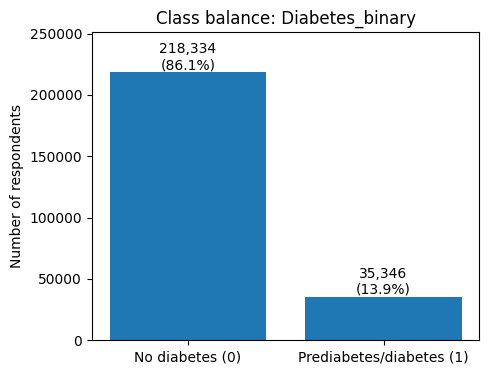

In [44]:
import matplotlib.pyplot as plt

# Visualization 1: class balance of the target variable
counts = df['Diabetes_binary'].value_counts().sort_index()
percentages = counts/counts.sum() * 100

labels = ['No diabetes (0)', 'Prediabetes/diabetes (1)']

plt.figure(figsize=(5, 4))
bars = plt.bar(labels, counts.values)

for bar, count, pct in zip(bars, counts.values, percentages.values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{count:,}\n({pct:.1f}%)",
        ha='center',
        va='bottom'
    )

plt.ylabel('Number of respondents')
plt.title('Class balance: Diabetes_binary')
plt.ylim(0, counts.max() * 1.15)  # headroom so labels don't get clipped
plt.show()

**Visualization 1: Class balance**

The target variable is heavily imbalanced: 86.1% of respondents (218,334) report no diabetes, while only 13.9% (35,346) report prediabetes or diabetes. This roughly 6-to-1 ratio means a classifier that simply predicted "no diabetes" for every respondent would still score 86.1% accuracy while catching zero true positive cases. This directly motivates not relying on accuracy alone as an evaluation metric and may call for class weighting or resampling during preprocessing.

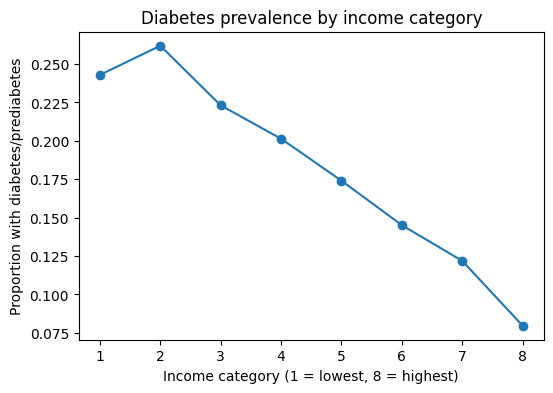

In [45]:
# Visualization 2: diabetes prevalence by income category
prevalence_by_income = df.groupby('Income')['Diabetes_binary'].mean()

plt.figure(figsize=(6, 4))
plt.plot(prevalence_by_income.index, prevalence_by_income.values, marker='o')
plt.xlabel('Income category (1 = lowest, 8 = highest)')
plt.ylabel('Proportion with diabetes/prediabetes')
plt.title('Diabetes prevalence by income category')
plt.show()


**Visualization 2: Diabetes prevalence by income category**

Within this sample, diabetes/prediabetes prevalence drops fairly steadily as income rises, from around 24-26% in the lowest income categories down to about 8% in the highest. Category 1 is a slight exception, sitting just below category 2 rather than at the peak. Because this reflects unweighted survey responses rather than weights applied for population representativeness, these figures describe patterns in the sample itself and shouldn't be read as calibrated estimates of true population prevalence by income group. The direction of the relationship is still informative, but the exact percentages would likely shift under proper survey weighting.

## 3. Data Quality Assessment

### 3.1. Missing Values
No missing values in this dataset

In [46]:
df.isnull().sum()

,0
HighBP,0
HighChol,0
CholCheck,0
BMI,0
Smoker,0
Stroke,0
HeartDiseaseorAttack,0
PhysActivity,0
Fruits,0
Veggies,0


### 3.2 Improperly coded observations
No improperly coded observations found in this dataset.

In [47]:
# Check each variable's observed values against its documented valid range.
# Binary variables should only contain {0, 1}; ordinal variables should fall
# within their documented category range.

binary_cols = ['Diabetes_binary','HighBP','HighChol','CholCheck','Smoker','Stroke',
               'HeartDiseaseorAttack','PhysActivity','Fruits','Veggies',
               'HvyAlcoholConsump','AnyHealthcare','NoDocbcCost','DiffWalk','Sex']

for col in binary_cols:
    vals = sorted(df[col].unique())
    if vals != [0, 1]:
        print(f"UNEXPECTED VALUES in {col}: {vals}")
    else:
      print(f"No unexpected values in binary column: {col}")

ordinal_ranges = {
    'GenHlth': (1, 5),
    'Age': (1, 13),
    'Education': (1, 6),
    'Income': (1, 8),
}

for col, (lo, hi) in ordinal_ranges.items():
    out_of_range = df[(df[col] < lo) | (df[col] > hi)]
    print(f"{col}: {len(out_of_range)} rows out of documented range [{lo}, {hi}]")

No unexpected values in binary column: Diabetes_binary
No unexpected values in binary column: HighBP
No unexpected values in binary column: HighChol
No unexpected values in binary column: CholCheck
No unexpected values in binary column: Smoker
No unexpected values in binary column: Stroke
No unexpected values in binary column: HeartDiseaseorAttack
No unexpected values in binary column: PhysActivity
No unexpected values in binary column: Fruits
No unexpected values in binary column: Veggies
No unexpected values in binary column: HvyAlcoholConsump
No unexpected values in binary column: AnyHealthcare
No unexpected values in binary column: NoDocbcCost
No unexpected values in binary column: DiffWalk
No unexpected values in binary column: Sex
GenHlth: 0 rows out of documented range [1, 5]
Age: 0 rows out of documented range [1, 13]
Education: 0 rows out of documented range [1, 6]
Income: 0 rows out of documented range [1, 8]


### 3.3 Anticipated preprocessing steps

The improperly-coded-observations check above came back completely clean: every binary variable contains only {0, 1}, and every ordinal variable (GenHlth, Age, Education, Income) falls within its documented range. Combined with the zero missing values from Section 3.1, this means preprocessing here is mostly about preparing the data for modeling, not cleaning it.

- **Scaling:** `BMI`, `MentHlth`, and `PhysHlth` are on different numeric scales than the 0/1 binary indicators (BMI roughly 12-98, MentHlth/PhysHlth 0-30 day counts). For any model sensitive to feature scale (logistic regression with regularization, KNN, SVM), I plan to standardize these three variables rather than leave them on their raw scales.
- **Encoding Age, Education, and Income:** these are ordered categories, not raw counts, but they're also not unordered labels. I plan to keep them as ordinal integers, since the category order is meaningful (higher code = higher income/education/age bracket).
- **Class imbalance:** given the roughly 86/14 split found in Section 2.6, I plan to address this at the modeling stage rather than by discarding data, most likely with `class_weight='balanced'` as a first pass, and comparing against SMOTE-based resampling if that isn't sufficient.
- **No imputation needed:** since there are no missing values and no out-of-range codes, there's no cleaning step required before the scaling/encoding steps above.


### 3.4 Potential challenges

- **Self-report bias:** `Smoker`, `Fruits`, `Veggies`, `HvyAlcoholConsump`, and `PhysActivity` are all self-reported, which introduces recall bias and social-desirability bias (respondents under- or over-reporting behaviors seen as unhealthy or healthy).
- **Single survey year:** this is a 2015 cross-section, so the dataset can't speak to trends over time or how any of these relationships have shifted since.
- **Class imbalance:** the ~86/14 split in the target means naive accuracy will be a misleading metric, and some models may default toward predicting the majority class without correction.
- **Unweighted sample:** BRFSS is a weighted survey, but this cleaned version doesn't carry the survey weights. That means the proportions seen in Section 2.6 describe patterns within this sample, not calibrated population-level estimates, which limits how strongly the income-prevalence relationship can be generalized.
- **Possible multicollinearity:** several health-status variables (`HighBP`, `HighChol`, `HeartDiseaseorAttack`, `GenHlth`) likely correlate with each other, which is worth checking before relying on individual coefficient interpretations in a linear model.


## 4. Project Planning

**Proposed prediction problem:** This project aims to predict whether an individual has diabetes or prediabetes using self-reported demographic, socioeconomic, behavioral, and health-status indicators from the BRFSS survey. Specifically, I'm interested in how much the socioeconomic variables, income, education, and healthcare access, contribute to that prediction alongside the more clinical and behavioral variables like BMI, blood pressure, and physical activity. The goal isn't just building a model that predicts well, but understanding which factors carry the most predictive weight, since that has direct implications for where prevention and outreach efforts might be targeted.

**Target variable:** The target variable is Diabetes_binary, where 0 means no diabetes and 1 means prediabetes or diabetes.

**Candidate evaluation metric:** The class balance check in Section 2.6 showed that about 86% of respondents fall in the "no diabetes" class and only about 14% fall in the "diabetes/prediabetes" class. That imbalance matters for metric choice: a model could predict "no diabetes" for every single respondent and still be right 86% of the time, while being completely useless at actually identifying at-risk people. So accuracy alone isn't a good measure of whether the model is doing its job here.

Instead, I plan to use recall (sensitivity) as the primary metric. Recall measures how many of the actual diabetes/prediabetes cases the model successfully catches. In a screening-type context like this, missing someone who actually has the condition (a false negative) is generally a more costly mistake than flagging someone who turns out not to have it (a false positive), since a false positive just means an extra follow-up check, while a false negative means a real case goes unnoticed. As a secondary metric, I'll also track AUC-ROC, which measures how well the model separates the two classes overall, independent of any single decision threshold, useful for comparing different models against each other before deciding where to set that threshold.